## Molecular Dynamics
### Author: Łukasz Grzegrzółka

### Euler Method

In this part of the assignment, the goal was to numerically solve the two‑body gravitational problem using the Euler method and to analyse the resulting orbital trajectory together with the time evolution of kinetic, potential, and total energy. The system consists of a light particle of mass (m = 0.1) moving in the gravitational field of a much heavier mass (M = 500), which is treated as fixed at the origin. The initial conditions $(x, y) = (2, 0)$ and $(p_x, p_y) = (0, 0.1)$ correspond to a particle starting at a finite distance with a small tangential momentum, which should ideally produce a bound, nearly elliptical orbit.

The Euler algorithm updates positions and momenta using a first‑order Taylor expansion, where the new position is computed from the current velocity and force, and the new momentum is obtained by adding the instantaneous force multiplied by the time step. Because the method is not symplectic and does not preserve phase‑space volume, numerical errors accumulate at every step. As a result, the simulated trajectory gradually deviates from the true solution of the gravitational problem. This behaviour is clearly visible in the phase‑space plots $(x, p_x)$ and $(y, p_y)$, where the curves do not form closed loops but instead drift outward, indicating a systematic error in the integration.

In [46]:
import numpy as np
import matplotlib.pyplot as plt

G = 0.01
M = 500.0
m = 0.1
dt = 0.001
steps = 100000

x0 = 2
y0=0
px0 = 0
py0 = 0.1

def Ek(px, py, mr=m):
    return (px**2 + py**2)/(2*mr)

def Ep(x, y, m1=m, m2=M):
    return -1*G*m1*m2/np.sqrt(x**2 + y**2)

#r = np.array()
X = np.zeros(steps)
X[0] = x0
Y = np.zeros(steps)
Y[0] = y0
Px = np.zeros(steps)
Px[0] = px0
Py = np.zeros(steps)
Py[0] = py0
T = np.zeros(steps)
E_k = np.zeros(steps)
E_k[0] = Ek(px0, py0)
E_p = np.zeros(steps)
E_p[0] = Ep(x0, y0)


def F(x, y, m1=m, m2=M, G=G):
    return -1*G*m1*m2*x/((x**2 + y**2)**(3/2)), -1*G*m1*m2*y/((x**2 + y**2)**(3/2))

def evolve(x, y, px, py, mr=m):
    rx, ry = x + px*dt/mr + dt**2/(2*mr)*F(x, y)[0], y + py*dt/mr + dt**2/(2*mr)*F(x, y)[1]
    px_1, py_1 = px + dt*F(x,y)[0], py + dt*F(x,y)[1]
    return rx, ry, px_1, py_1

In [47]:
for i in range(steps-1):
    n_x, n_y, n_px, n_py = evolve(X[i], Y[i], Px[i], Py[i])
    X[i+1] = n_x
    Px[i+1] = n_px
    Y[i+1] = n_y
    Py[i+1] = n_py
    T[i+1] = T[i] + dt
    E_k[i+1] = Ek(n_px, n_py)
    E_p[i+1] = Ep(n_x, n_y)

E_c = E_p+E_k

### Orbital trajectories and phase space diagram plots

The orbital plot $y(x)$ shows that the trajectory slowly spirals away from the central mass instead of remaining on a stable closed orbit. This is a characteristic artefact of the Euler method: because it does not conserve energy, the particle gains or loses energy over time in an unphysical way. This effect becomes even more apparent when examining the time evolution of the energies. The potential energy $E_p(T)$ and kinetic energy $E_k(T)$ both exhibit noticeable fluctuations, and the total energy $E_c(T)$, which should remain constant for an isolated two‑body system, drifts steadily as the simulation progresses. The monotonic change in total energy is a direct manifestation of the numerical instability inherent to the Euler scheme.

These results illustrate why the Euler method is generally unsuitable for long‑term simulations of Hamiltonian systems such as gravitational motion. Its lack of time‑reversibility and failure to conserve energy lead to qualitatively incorrect trajectories, especially over many integration steps.

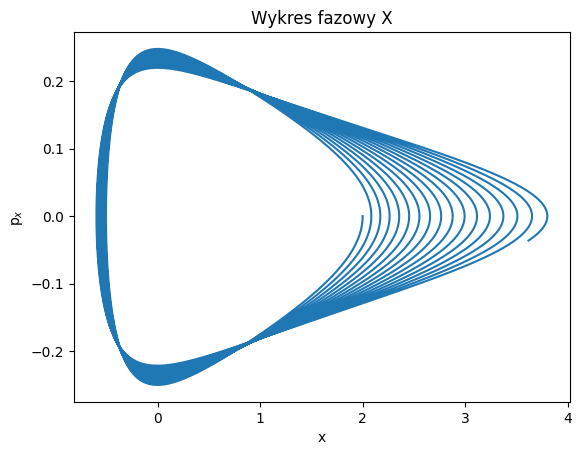

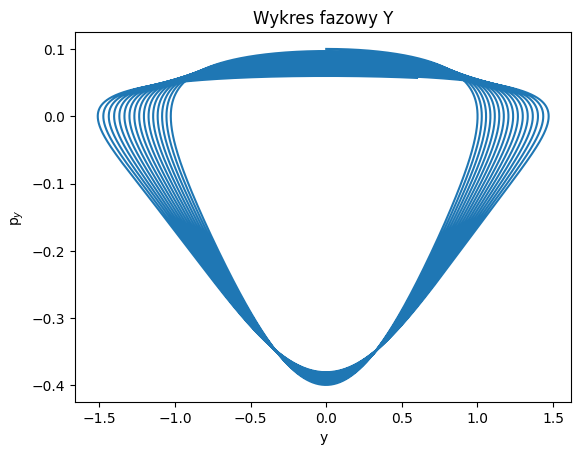

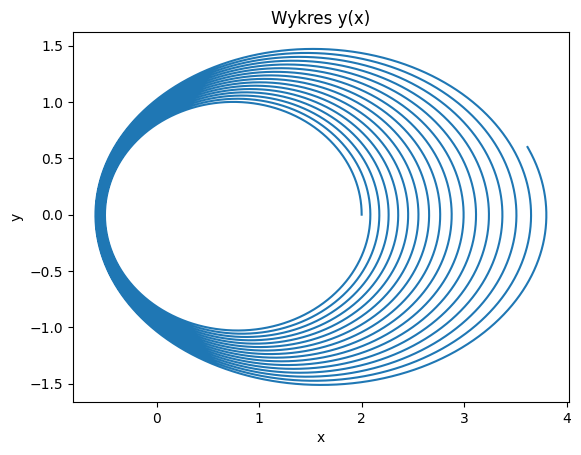

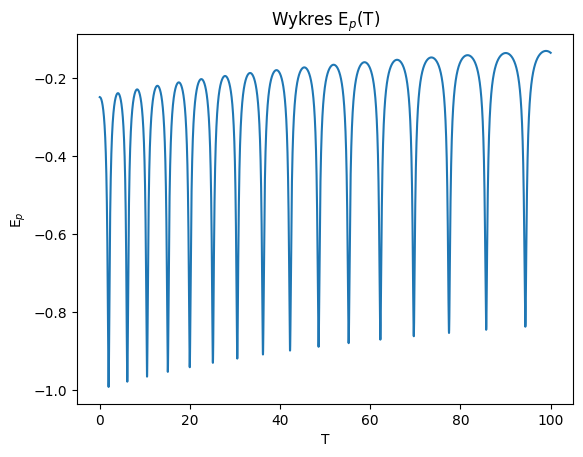

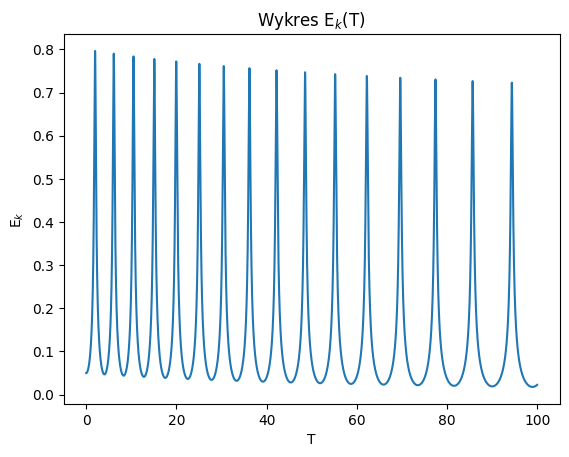

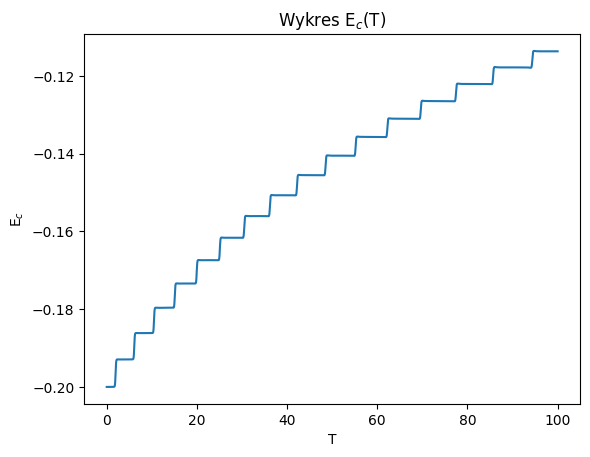

In [48]:
plt.plot(X, Px)
plt.title("Wykres fazowy X")
plt.xlabel("x")
plt.ylabel("p$_{x}$")
plt.show()

plt.plot(Y, Py)
plt.title("Wykres fazowy Y")
plt.xlabel("y")
plt.ylabel("p$_{y}$")
plt.show()

plt.plot(X, Y)
plt.title("Wykres y(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

plt.plot(T, E_p)
plt.title("Wykres E$_{p}$(T)")
plt.xlabel("T")
plt.ylabel("E$_{p}$")
plt.show()

plt.plot(T, E_k)
plt.title("Wykres E$_{k}$(T)")
plt.xlabel("T")
plt.ylabel("E$_{k}$")
plt.show()

plt.plot(T, E_c)
plt.title("Wykres E$_{c}$(T)")
plt.xlabel("T")
plt.ylabel("E$_{c}$")
plt.show()




### Verlet algorithm

The Verlet algorithm is another numerical method for integrating Newton’s equations of motion, particularly in systems where long‑term stability and energy conservation are essential. Unlike the simple Euler method, which updates positions and velocities independently and accumulates numerical errors rapidly, the Verlet scheme is based on a symmetric finite‑difference approximation. The position at the next time step is computed from the current and previous positions, together with the force evaluated at the current point. This leads to the update rule:

$\mathbf{r}(t+\Delta t) = 2\mathbf{r}(t) - \mathbf{r}(t-\Delta t) + \frac{\Delta t^2}{m},\mathbf{F}(t)$,

which is time‑reversible and preserves phase‑space volume. Because velocities do not explicitly appear in the update, they are reconstructed only when needed, typically using a centered finite difference. This structure makes the Verlet algorithm particularly suitable for Hamiltonian systems such as gravitational motion.

In [49]:
import numpy as np
import matplotlib.pyplot as plt

G = 0.01
M = 500.0
m = 0.1
dt = 0.001
steps = 100000

def V(x_1, y_1, x__1, y__1):
    vx = (x_1 - x__1) / (2*dt)
    vy = (y_1 - y__1) / (2*dt)
    return vx, vy

def Ek(x_1, y_1, x__1, y__1, mr=m):
    vx, vy = V(x_1, y_1, x__1, y__1)
    return mr * (vx**2 + vy**2) / 2

def Ep(x, y, m1=m, m2=M):
    return -G * m1 * m2 / np.sqrt(x**2 + y**2)

def F(x, y, m1=m, m2=M, G=G):
    r3 = (x**2 + y**2)**(3/2)
    return -G*m1*m2*x/r3, -G*m1*m2*y/r3

def evolve(x, y, x_1, y_1, mr=m):
    Fx, Fy = F(x, y)
    rx = 2*x - x_1 + dt**2/mr * Fx
    ry = 2*y - y_1 + dt**2/mr * Fy
    return rx, ry


### Simulations with Verlet algorithm

In [50]:
X = np.zeros(steps)
Y = np.zeros(steps)
T = np.zeros(steps)
E_k = np.zeros(steps)
E_p = np.zeros(steps)


X[0] = x0 - px0*dt/m
X[1] = x0
Y[0] = y0 - py0*dt/m
Y[1] = y0

E_p[0] = Ep(X[0], Y[0])
E_p[1] = Ep(X[1], Y[1])
E_k[1] = Ek(X[1], Y[1], X[0], Y[0])


for i in range(1, steps-1):
    X[i+1], Y[i+1] = evolve(X[i], Y[i], X[i-1], Y[i-1])
    T[i+1] = T[i] + dt
    E_p[i+1] = Ep(X[i+1], Y[i+1])
    E_k[i+1] = Ek(X[i+1], Y[i+1], X[i-1], Y[i-1])

E_p = E_p[2:]
E_k = E_k[2:]
E_c = E_p + E_k
T=T[2:]

### Plots

In the simulation of the two‑body gravitational problem, the Verlet method produces a qualitatively correct orbital trajectory. Starting from the initial conditions $(x, y) = (2, 0)$ and a small tangential momentum, the particle follows a smooth, closed curve around the central mass. The plot of $y(x)$ shows an orbit that remains bounded and does not exhibit the unphysical spiraling behaviour characteristic of the Euler method. This indicates that the Verlet integrator maintains the correct balance between kinetic and potential energy over long time intervals.

The time evolution of the energies further illustrates the strengths of the method. The potential energy $E_p(T)$ and kinetic energy $E_k(T)$ oscillate periodically, reflecting the natural exchange between these two forms of energy in a bound gravitational system. Most importantly, the total energy $E_c(T)$ remains nearly constant throughout the simulation. Although small numerical fluctuations are present, they are bounded and do not accumulate over time. This behaviour is a direct consequence of the symplectic nature of the Verlet algorithm, which ensures that the numerical trajectory stays close to a true physical trajectory with slightly perturbed initial conditions.

Despite its advantages, the Verlet method also has limitations. Because velocities are not part of the primary update step, they must be reconstructed from positions, which introduces a small additional numerical error. This can complicate analyses that rely directly on accurate instantaneous velocities.

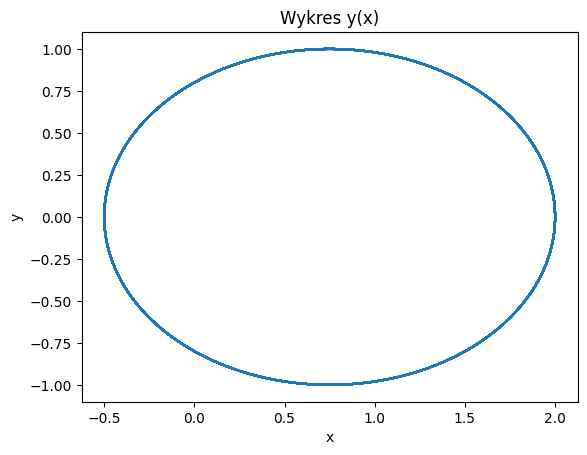

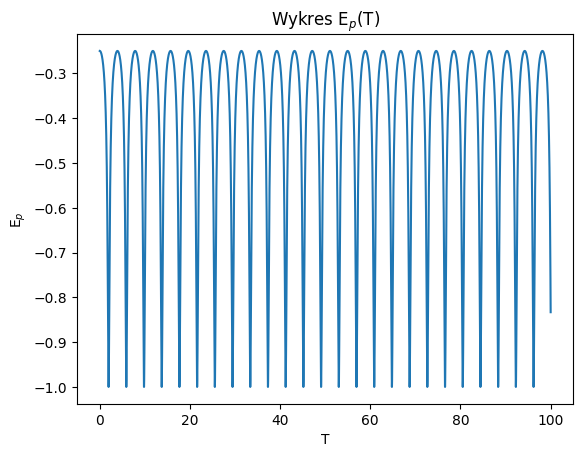

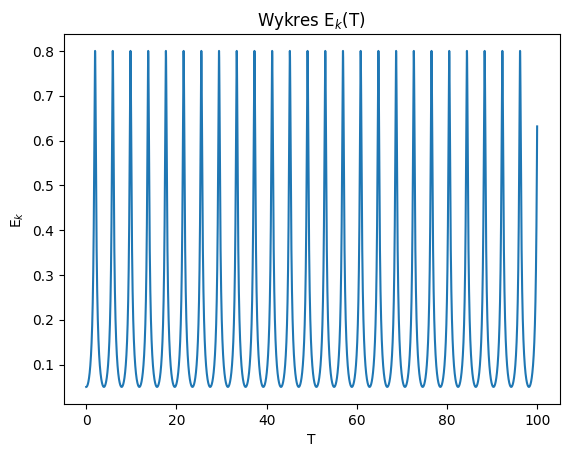

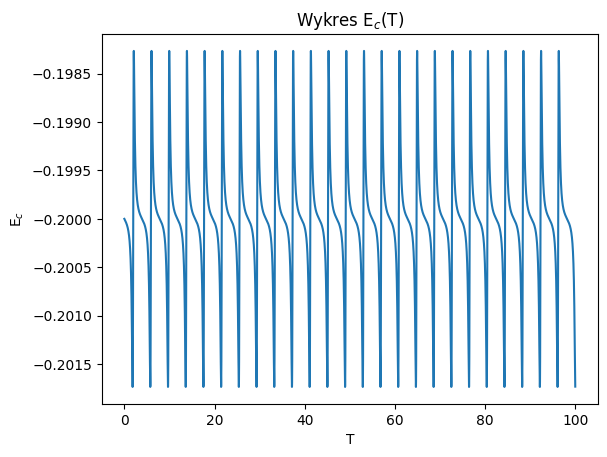

In [51]:
plt.plot(X, Y)
plt.title("Wykres y(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

plt.plot(T, E_p)
plt.title("Wykres E$_{p}$(T)")
plt.xlabel("T")
plt.ylabel("E$_{p}$")
plt.show()

plt.plot(T, E_k)
plt.title("Wykres E$_{k}$(T)")
plt.xlabel("T")
plt.ylabel("E$_{k}$")
plt.show()

plt.plot(T, E_c)
plt.title("Wykres E$_{c}$(T)")
plt.xlabel("T")
plt.ylabel("E$_{c}$")
plt.show()

### Leapfrog algorithm

The leapfrog algorithm is a numerical integrator widely used in simulations of Hamiltonian systems, including gravitational dynamics and molecular dynamics. Its defining feature is the staggered update of positions and velocities: velocities are evaluated at half‑time steps, while positions are evaluated at full time steps. This structure ensures that the algorithm preserves phase‑space volume and remains time‑reversible, which are essential properties for maintaining long‑term stability in conservative systems.

The method begins by shifting the initial velocity backward by half a time step:

$\mathbf{v}\left(t-\tfrac{\Delta t}{2}\right) = \mathbf{v}(t) - \frac{\Delta t}{2m} \mathbf{F}(t)$

after which the evolution proceeds through the leapfrog cycle: 

$\mathbf{v}\left(t+\tfrac{\Delta t}{2}\right) = \mathbf{v}\left(t-\tfrac{\Delta t}{2}\right) + \frac{\Delta t}{m} \mathbf{F}(t) $

$\mathbf{r}(t+\Delta t) = \mathbf{r}(t) + \mathbf{v}\left(t+\tfrac{\Delta t}{2}\right) \Delta t $.

Because the force depends only on the current position, each step requires only one force evaluation, making the algorithm computationally efficient. Velocities at full time steps can be reconstructed by averaging the half‑step velocities, which is sufficient for computing kinetic energy or other dynamical quantities.

Despite its advantages, the leapfrog algorithm also has limitations. Because positions and velocities are evaluated at different times, the method can be less convenient when precise velocity values at specific time points are required. 

In [52]:
import numpy as np
import matplotlib.pyplot as plt

G = 0.01
M = 500.0
m = 0.1
dt = 0.001
steps = 100000

def Ek(vx, vy, mr=m):
    return mr*(vx**2 + vy**2)/2

def Ep(x, y, m1=m, m2=M):
    return -G*m1*m2/np.sqrt(x**2 + y**2)

def F(x, y, m1=m, m2=M, G=G):
    r3 = (x**2 + y**2)**(3/2)
    return -G*m1*m2*x/r3, -G*m1*m2*y/r3

def evolve(x, y, vx_prev, vy_prev, mr=m):
    Fx, Fy = F(x, y)
    vx_new = vx_prev + dt * Fx / mr
    vy_new = vy_prev + dt * Fy / mr
    rx = x + vx_new * dt
    ry = y + vy_new * dt
    vxc = 0.5 * (vx_new + vx_prev)
    vyc = 0.5 * (vy_new + vy_prev)
    return rx, ry, vx_new, vy_new, vxc, vyc


### Numerical simulations with leapfrog algorithm

In [53]:
X = np.zeros(steps)
Y = np.zeros(steps)
Vx = np.zeros(steps)
Vy = np.zeros(steps)
Vxc = np.zeros(steps)
Vyc = np.zeros(steps)
T = np.zeros(steps)
E_k = np.zeros(steps)
E_p = np.zeros(steps)

x0 = 2
y0 = 0
vx0 = 0
vy0 = 1
X[0] = x0
Y[0] = y0

Fx0, Fy0 = F(x0, y0)

# Leapfrog: v(t - dt/2) = v(t) - (dt/2)*a(t)
Vx[0] = vx0 - 0.5 * dt * Fx0 / m
Vy[0] = vy0 - 0.5 * dt * Fy0 / m

E_p[0] = Ep(x0, y0)
E_k[0] = Ek(vx0, vy0)   # energy in full step


for i in range(steps - 1):
    X[i+1], Y[i+1], Vx[i+1], Vy[i+1], Vxc[i], Vyc[i] = evolve(
        X[i], Y[i], Vx[i], Vy[i]
    )
    T[i+1] = T[i] + dt
    E_p[i+1] = Ep(X[i+1], Y[i+1])
    E_k[i+1] = Ek(Vxc[i], Vyc[i])

#last step
Vxc[-1] = 0.5 * (Vx[-1] + Vx[-2])
Vyc[-1] = 0.5 * (Vy[-1] + Vy[-2])
E_k[-1] = Ek(Vxc[-1], Vyc[-1])

E_c = E_p + E_k

### Plots

In the simulation of the two‑body gravitational problem, the leapfrog method produces a stable and physically meaningful orbit. The plot of (y(x)) shows a smooth, closed trajectory characteristic of a bound Keplerian orbit. Unlike the Euler method, which introduces systematic energy drift and causes the orbit to spiral outward or inward, the leapfrog integrator maintains the correct orbital shape over long time intervals. This behaviour reflects the symplectic nature of the method, which ensures that numerical errors do not accumulate monotonically but instead remain bounded.

The time evolution of the energies further confirms the good performance of the algorithm. The potential energy (E_p(T)) and kinetic energy (E_k(T)) oscillate periodically, reflecting the natural exchange between these two forms of energy as the particle moves along its orbit. The total energy (E_c(T)) remains nearly constant, with only small fluctuations around a fixed value. These fluctuations are expected and arise from the finite time step, but they do not grow over time. The stability of the total energy is one of the key indicators that the leapfrog method is well suited for long‑term integration of conservative systems.

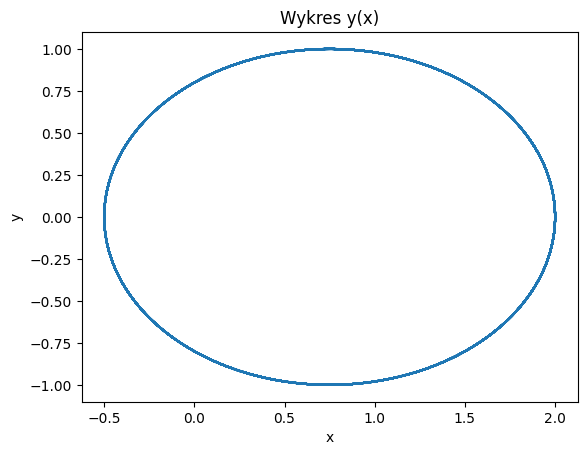

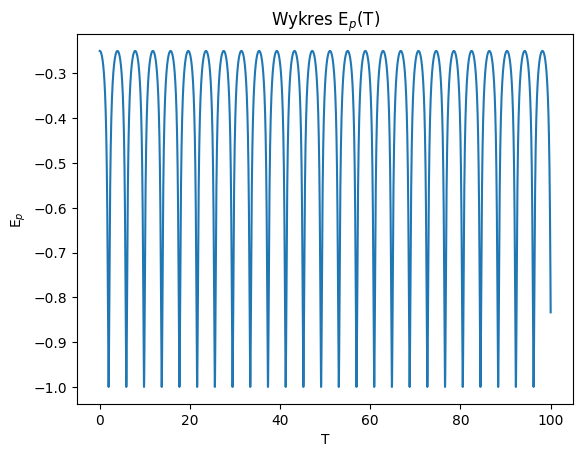

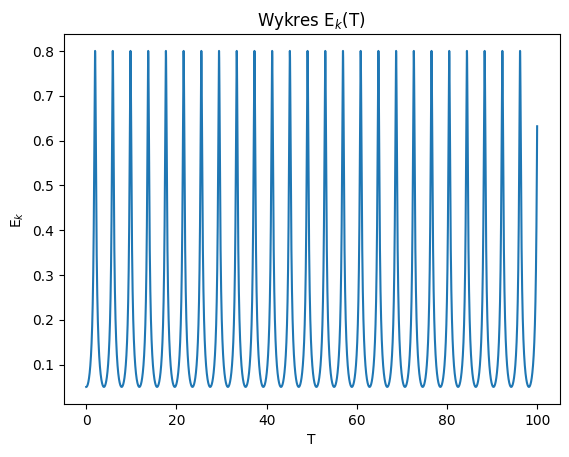

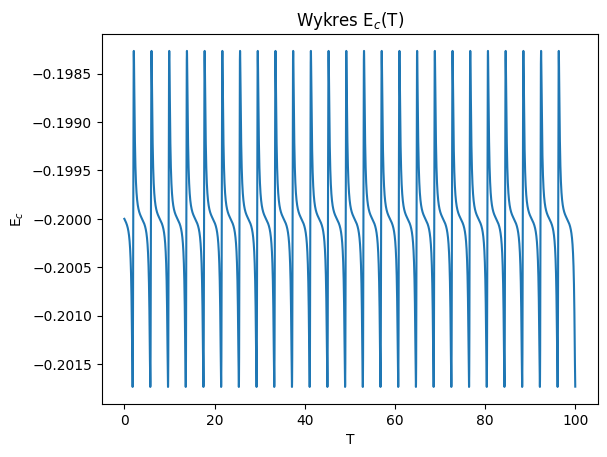

In [55]:
plt.plot(X, Y)
plt.title("Wykres y(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

plt.plot(T, E_p)
plt.title("Wykres E$_{p}$(T)")
plt.xlabel("T")
plt.ylabel("E$_{p}$")
plt.show()

plt.plot(T, E_k)
plt.title("Wykres E$_{k}$(T)")
plt.xlabel("T")
plt.ylabel("E$_{k}$")
plt.show()

plt.plot(T, E_c)
plt.title("Wykres E$_{c}$(T)")
plt.xlabel("T")
plt.ylabel("E$_{c}$")
plt.show()


### Three‑Body Simulation Using the Verlet Algorithm

The three‑body problem is a classical example of a nonlinear dynamical system in which even simple initial conditions can lead to highly complex trajectories. In this simulation, the goal was to reproduce the well‑known Chenciner–Montgomery figure‑eight orbit, a remarkable periodic solution discovered for three equal masses interacting through Newtonian gravity. The system is initialized with the standard symmetric initial conditions that place the three bodies on a collision‑free, periodic trajectory. Because the gravitational interaction is conservative and the motion is highly sensitive to numerical errors, the choice of integration method is crucial.

The simulation uses the Verlet algorithm, which is well suited for Hamiltonian systems. Because the Verlet scheme is time‑reversible and symplectic, it preserves phase‑space volume and exhibits good long‑term stability. This is essential for the three‑body problem, where even small numerical errors can cause trajectories to diverge exponentially due to the system’s chaotic nature.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

G = 1
m = 1
dt = 0.001
N = 10000

T = np.zeros(N+1)
E_p = np.zeros(N)
E_k = np.zeros(N)

r1 = np.array([0.97000436, -0.24308753])
r2 = np.array([-0.97000436, +0.24308753])
r3 = np.array([0, 0])

v1 = np.array([-0.93240737/2, -0.86473146/2])
v2 = np.array([-0.93240737/2, -0.86473146/2])
v3 = np.array([0.93240737, 0.86473146])

R1 = np.zeros((N+2, 2))
R2 = np.zeros((N+2, 2))
R3 = np.zeros((N+2, 2))

R1[0] = r1-v1*dt
R2[0] = r2-v2*dt
R3[0] = r3-v3*dt
R1[1] = r1
R2[1] = r2
R3[1] = r3

def Ep(r1, r2, r3):
    return -1*(1/np.sqrt(np.dot(r1-r2, r1-r2)) + 1/np.sqrt(np.dot(r1-r3, r1-r3)) + 1/np.sqrt(np.dot(r3-r2, r3-r2)) )

def V(r_1, r__1):
    return (r_1-r__1)/(2*dt)

def Ek(r_1, r_2, r_3, r__1, r__2,r__3):
    return m*( np.dot(V(r_1, r__1), V(r_1, r__1)) + np.dot(V(r_2, r__2), V(r_2, r__2)) + np.dot(V(r_3, r__3), V(r_3, r__3)) )/2

def F(r, r1, r2):
    return -1 * ( (r-r1)/(np.sqrt(np.dot(r-r1, r-r1)))**3 + (r-r2)/(np.sqrt(np.dot(r-r2, r-r2)))**3 )

def evolve(r1, r2, r3, r1_1, r2_1, r3_1):
    rn1 = 2*r1 - r1_1 + F(r1, r2, r3)*dt**2
    rn2 = 2*r2 - r2_1 + F(r2, r1, r3)*dt**2
    rn3 = 2*r3 - r3_1 + F(r3, r2, r1)*dt**2
    return rn1, rn2, rn3

for i in range(N):
    E_p[i] = Ep(R1[i+1], R2[i+1], R3[i+1])
    R1[i+2], R2[i+2], R3[i+2] = evolve(R1[i+1], R2[i+1], R3[i+1], R1[i], R2[i], R3[i])
    T[i+1] = T[i]+dt
    E_k[i] = Ek(R1[i+2], R2[i+2], R3[i+2], R1[i], R2[i], R3[i])

E_c = E_p + E_k
T = np.delete(T, -1)


### Plots

The resulting trajectories of the three bodies form the characteristic figure‑eight pattern. Each mass follows the same closed curve, shifted in phase by one third of the period, producing a symmetric and aesthetically striking motion. The plotted paths confirm that the Verlet integrator is capable of maintaining the delicate balance required for this orbit: the bodies repeatedly pass through the center of mass without colliding, and the overall structure remains stable over many cycles.

The energy plots provide further insight into the numerical behaviour of the algorithm. The potential energy $E_p(T)$ and kinetic energy $E_k(T)$ both oscillate strongly, reflecting the periodic stretching and compression of the configuration as the bodies move along the figure‑eight. Importantly, the total energy $E_c(T)$ remains nearly constant throughout the simulation.

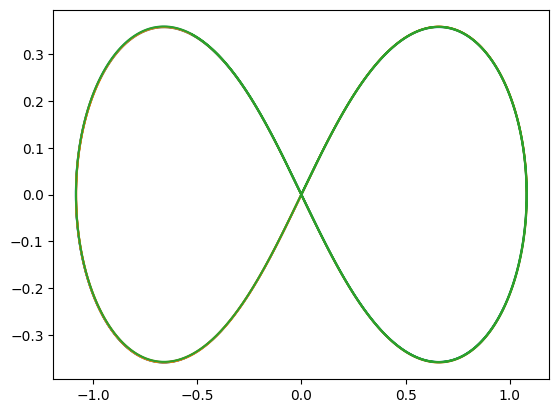

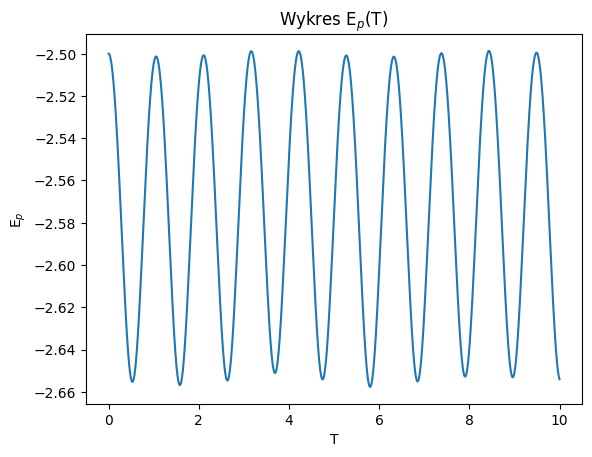

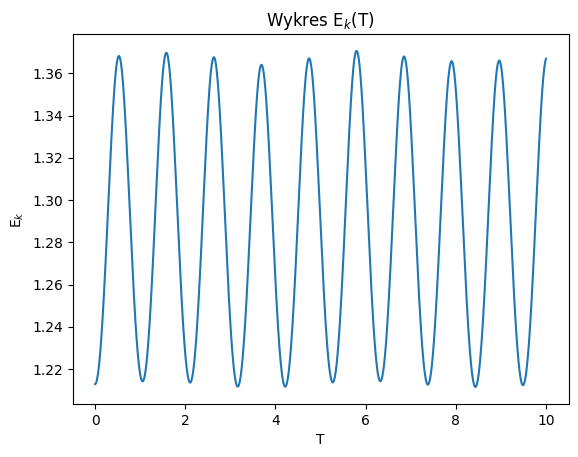

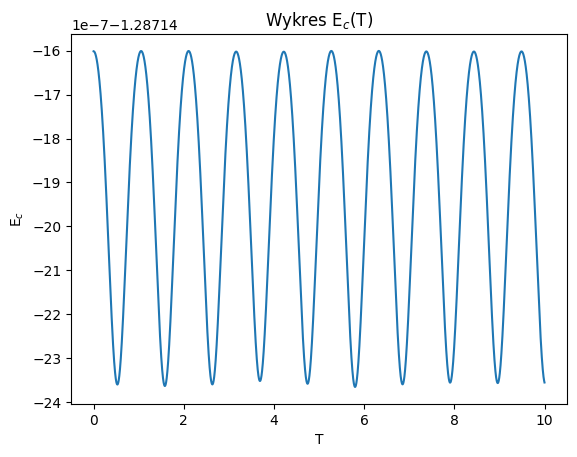

In [2]:
plt.plot(R1[:,0], R1[:,1])
plt.plot(R2[:,0], R2[:,1])
plt.plot(R3[:,0], R3[:,1])
plt.show()

plt.plot(T, E_p)
plt.title("Wykres E$_{p}$(T)")
plt.xlabel("T")
plt.ylabel("E$_{p}$")
plt.show()

plt.plot(T, E_k)
plt.title("Wykres E$_{k}$(T)")
plt.xlabel("T")
plt.ylabel("E$_{k}$")
plt.show()

plt.plot(T, E_c)
plt.title("Wykres E$_{c}$(T)")
plt.xlabel("T")
plt.ylabel("E$_{c}$")
plt.show()